# Analysing Individual Objective Functions

In [21]:
from math import floor

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

# load the data
df = pd.read_csv("Data\\MPAA_model_data.csv")

df['carbon index norm'] = df['carbon index norm'].fillna(df['carbon index norm'].mean())

# List of municipalities IDs
municipalities = df['NM_MUN'].tolist()

# Biodiversity score for each municipality Bio_i
Bio = df.set_index('NM_MUN')['biodiversity_priority_index'].to_dict()

# Extinction risk normalised E_hat_i
E_hat = df.set_index('NM_MUN')['Extinction risk score norm'].to_dict()

# Carbon sequestration potential for each municipality Car_hat_i
Car_hat = df.set_index('NM_MUN')['carbon index norm'].to_dict()

# Land available for planting in each municipality A_i
A = df.set_index('NM_MUN')['eligible_area_ha_mapbiomas'].to_dict()

# Urgency score U_hat_i
U_hat = df.set_index('NM_MUN')['urgency_5yr_index'].to_dict()

# Reversal risk Rev_hat_i
Rev_hat = df.set_index('NM_MUN')['reversal_risk'].to_dict()

# cost per hectare for each municipality c_i
c = df.set_index('NM_MUN')['cost_per_ha'].to_dict()

# max cost per hectare across all municipalities (for cost-effectiveness)
c_max = max(c.values())
c_max

# ========================= Fixed Additional Parameters ======================== 
B = 489850000  # Total budget in dollars
m = 200    # Minimum viable project scale in hectares
K = 560000 # Updated based on new data and assumptions - can implement up to 560,000 hectares per year across all municipalities
N_min = 25       # Minimum number of municipalities to fund (Fairness constraint)
theta = 0.20  # No municipality can receive more than 20% of the total budget B

# weight constraints
alpha_B = 0.5      # Weight for Biodiversity
beta_B = 0.5       # Weight for Extinction Risk

# Relaxation / Tolerance parameters for lexicographic steps (e.g., 0.05 = 5% tolerance)
#gamma_1 = 0.05  # Tolerance for degrading Biodiversity
#gamma_2 = 0.05  # Tolerance for degrading Carbon
#gamma_3 = 0.05  # Tolerance for degrading Urgency

In [22]:
arc_municipalities = [
    "Abaetetuba",
    "Abel Figueiredo",
    "Acará",
    "Ananindeua",
    "Aurora do Pará",
    "Bagre",
    "Baião",
    "Barcarena",
    "Belém",
    "Benevides",
    "Bom Jesus do Tocantins",
    "Brejo Grande do Araguaia",
    "Breu Branco",
    "Bujaru",
    "Cametá",
    "Canaã dos Carajás",
    "Conceição do Araguaia",
    "Concórdia do Pará",
    "Curionópolis",
    "Eldorado do Carajás",
    "Floresta do Araguaia",
    "Goianésia do Pará",
    "Igarapé-Miri",
    "Inhangapi",
    "Irituia",
    "Itupiranga",
    "Jacundá",
    "Limoeiro do Ajuru",
    "Mãe do Rio",
    "Marituba",
    "Mocajuba",
    "Moju",
    "Nova Ipixuna",
    "Oeiras do Pará",
    "Palestina do Pará",
    "Piçarra",
    "Salvaterra",
    "Santa Bárbara do Pará",
    "Santa Izabel do Pará",
    "São Domingos do Araguaia",
    "São Domingos do Capim",
    "São Geraldo do Araguaia",
    "São João do Araguaia",
    "Sapucaia",
    "Tailândia",
    "Tomé-Açu",
    "Tucuruí",
    "Xinguara",
    "Água Azul do Norte",
    "Anajás",
    "Anapu",
    "Bannach",
    "Bonito",
    "Breves",
    "Cachoeira do Arari",
    "Castanhal",
    "Chaves",
    "Colares",
    "Cumaru do Norte",
    "Curralinho",
    "Gurupá",
    "Marabá",
    "Melgaço",
    "Muaná",
    "Novo Repartimento",
    "Ourém",
    "Ourilândia do Norte",
    "Pacajá",
    "Parauapebas",
    "Pau D'Arco",
    "Ponta de Pedras",
    "Portel",
    "Porto de Moz",
    "Redenção",
    "Rio Maria",
    "Santa Cruz do Arari",
    "Santa Luzia do Pará",
    "Santa Maria das Barreiras",
    "Santana do Araguaia",
    "Santo Antônio do Tauá",
    "São Caetano de Odivelas",
    "São Félix do Xingu",
    "São Francisco do Pará",
    "São Miguel do Guamá",
    "São Sebastião da Boa Vista",
    "Senador José Porfírio",
    "Soure",
    "Vigia",
    "Capitão Poço",
    "Dom Eliseu",
    "Garrafão do Norte",
    "Ipixuna do Pará",
    "Nova Esperança do Piriá",
    "Paragominas",
    "Rondon do Pará",
    "Ulianópolis",
    "Viseu"]

In [23]:
dist_df = pd.read_csv("Data\\distance_matrix_named.csv", index_col=0)

# --- 1. SPATIAL PRE-COMPUTATION ---
D_max = 250.0
valid_pairs = []
inv_dist = {}

# Ensure IDs are strings to prevent lookup errors
mun_ids = [str(m) for m in municipalities]
dist_df.index = dist_df.index.astype(str)
dist_df.columns = dist_df.columns.astype(str)

for i in mun_ids:
    for j in mun_ids:
        if i < j: # Ensures we only check each unique pair once
            try:
                dij = float(dist_df.at[i, j])
                if 0 < dij <= D_max:
                    valid_pairs.append((i, j))
                    inv_dist[(i, j)] = 1.0 / dij
            except Exception:
                continue

print(f"Generated {len(valid_pairs)} valid spatial pairs within {D_max}km threshold.")

Generated 2850 valid spatial pairs within 250.0km threshold.


In [24]:
import geopandas as gpd
municipalities_gdf = gpd.read_file("Data\\BR_Municipios_2024.shp")

# Filter Pará and project to metric CRS (meters
para_gdf = municipalities_gdf[municipalities_gdf["NM_UF"] == "Pará"].copy()
    
len(para_gdf)

144

## Base Model

In [25]:
# --- 2. BASE MODEL CREATION FUNCTION ---
def create_base_model(sense=pulp.LpMaximize):
    model = pulp.LpProblem("PMV_Hierarchical_Model", sense)

    # ==========================================
    # 1. Decision Variables
    # ==========================================
    x = pulp.LpVariable.dicts("x", mun_ids, lowBound=0, cat=pulp.LpContinuous)
    
    y = pulp.LpVariable.dicts("y", mun_ids, cat=pulp.LpBinary)
    
    z = pulp.LpVariable.dicts("z", valid_pairs, lowBound=0, upBound=1, cat=pulp.LpContinuous)

    # ==========================================
    # 2. Core Constraints
    # ==========================================
    # Budget and Capacity Limits
    model += pulp.lpSum(c[i] * x[i] for i in mun_ids) <= B, "Budget_Limit"
    model += pulp.lpSum(x[i] for i in mun_ids) <= K, "Global_Capacity_Limit"
    
    # Geographic Equity Threshold
    model += pulp.lpSum(y[i] for i in mun_ids) >= N_min, "Min_Municipalities"

    # Arc of Deforestation Ring-fenced Minimum
    valid_arc_muns = [i for i in arc_municipalities if str(i) in c]
    model += pulp.lpSum(c[str(i)] * x[str(i)] for i in valid_arc_muns) >= 12350000, "Arc_Minimum"

    # ==========================================
    # 3. Logical Bounds
    # ==========================================
    for i in mun_ids:
        # Cannot restore more than eligible area
        model += x[i] <= A[i] * y[i], f"Upper_Bound_Area_{i}"
        
        # Must meet minimum viable scale if selected
        model += x[i] >= m * y[i], f"Min_Viable_Scale_{i}"

        # No municipality can receive more than theta share of total budget
        model += c[i] * x[i] <= theta * B, f"Max_Budget_Share_{i}"

    # ==========================================
    # 4. Fortet–Glover Linearisation for z_ij
    # ==========================================
    for (i, j) in valid_pairs:
        model += z[(i, j)] <= y[i], f"FG_Upper_i_{i}_{j}"
        model += z[(i, j)] <= y[j], f"FG_Upper_j_{i}_{j}"
        
        # This forces z up to 1 when both y[i] and y[j] are 1
        model += z[(i, j)] >= y[i] + y[j] - 1, f"FG_Lower_{i}_{j}"

    # ==========================================
    # 5. Objective Expressions
    # ==========================================
    # Storing these as lpSum expressions rather than variables saves matrix rows in Gurobi
    obj_bio = pulp.lpSum((alpha_B * Bio[i] + beta_B * E_hat[i]) * x[i] for i in mun_ids)
    obj_urg = pulp.lpSum(U_hat[i] * x[i] for i in mun_ids)
    obj_car = pulp.lpSum(Car_hat[i] * x[i] for i in mun_ids)
    obj_rev = pulp.lpSum(Rev_hat[i] * x[i] for i in mun_ids)
    
    # Spatial penalty is only calculated for pairs within D_max
    obj_spatial = pulp.lpSum(z[(i, j)] * inv_dist[(i, j)] for (i, j) in valid_pairs)

    return model, x, y, obj_bio, obj_urg, obj_car, obj_rev, obj_spatial

In [ ]:
print("--- STEP 1: Constructing Payoff Table ---")
objectives = ['Biodiversity and Extinction', 'Carbon', 'Urgency', 'Reversal Risk', 'Spatial Penalty']
payoff_table = {}
decision_vars = {}  # stores allocation decisions per objective solve

for obj_name in objectives:
# Set sense based on objective (Reversal Risk and Spatial Penalty minimised)
    sense = pulp.LpMinimize if obj_name == 'Reversal Risk' or obj_name == 'Spatial Penalty' else pulp.LpMaximize
    model, x, y, obj_bio_and_extinction, obj_urg, obj_car, obj_rev, obj_spatial = create_base_model(sense)

    if obj_name == 'Biodiversity and Extinction':   
        model += obj_bio_and_extinction
    elif obj_name == 'Carbon':      
        model += obj_car
    elif obj_name == 'Urgency':      
        model += obj_urg
    elif obj_name == 'Reversal Risk':      
        model += obj_rev
    elif obj_name == 'Spatial Penalty':      
        model += obj_spatial


    model.solve(pulp.GUROBI(msg=True))

    if model.status == pulp.LpStatusOptimal:
        print(f"Optimal solution found for objective: {obj_name}")
        payoff_table[obj_name] = {
            'Bio_and_extinction_val': pulp.value(obj_bio_and_extinction),
            'Car_val': pulp.value(obj_car),
            'Urg_val': pulp.value(obj_urg),
            'Rev_val': pulp.value(obj_rev),
            'Spatial_val': pulp.value(obj_spatial)
            }

        # Capture decision variable values for selected municipalities
        allocations = []
        for i in municipalities:
            y_val = y[i].varValue # binary variable indicating if municipality i is selected
            x_val = x[i].varValue # area allocated to municipality i
            if y_val is not None and y_val > 0.5: # selected municipality (binary variable)
                allocations.append({
                    'Municipality': i,
                    'Area_ha': x_val,
                    'Cost': c[i] * x_val
                })

        # Store the allocations in a DataFrame for this objective
        decision_vars[obj_name] = pd.DataFrame(allocations).sort_values('Area_ha', ascending=False).reset_index(drop=True)
    else:
        print(f"Warning: Base model infeasible when optimizing for {obj_name}")

# Print objective payoff table
print("\n--- Objective Payoff Table ---")
print(pd.DataFrame(payoff_table).T.to_string())

# Print decision variable summary per objective
print("\n--- Decision Variable Summary per Objective ---")
for obj_name, alloc_df in decision_vars.items():
    total_cost  = alloc_df['Cost'].sum()
    total_area  = alloc_df['Area_ha'].sum()
    n_selected  = len(alloc_df)
    print(f"\n[{obj_name}]  Selected: {n_selected} municipalities | "
          f"Total Area: {total_area:,.0f} ha | Total Cost: ${total_cost:,.0f}")
    print(alloc_df.to_string(index=False))


# NADIR UTOPIA Values for each objective 
bio_and_extinction_nadir = min(val['Bio_and_extinction_val'] for val in payoff_table.values())
bio_and_extinction_utopia = max(val['Bio_and_extinction_val'] for val in payoff_table.values())

car_nadir = min(val['Car_val'] for val in payoff_table.values())
car_utopia = max(val['Car_val'] for val in payoff_table.values())

urg_nadir = min(val['Urg_val'] for val in payoff_table.values())
urg_utopia = max(val['Urg_val'] for val in payoff_table.values())

# Reversal Risk and Spatial Penalty are minimised, so their nadir is the max value and utopia is the min value
rev_nadir = max(val['Rev_val'] for val in payoff_table.values())
rev_utopia = min(val['Rev_val'] for val in payoff_table.values())

spatial_nadir = max(val['Spatial_val'] for val in payoff_table.values())
spatial_utopia = min(val['Spatial_val'] for val in payoff_table.values())

# saves key values to csv
nadir_utopia_df = pd.DataFrame({
    'Objective': ['Bio_and_extinction', 'Carbon', 'Urgency', 'Reversal Risk', 'Spatial Penalty'],
    'Nadir': [bio_and_extinction_nadir, car_nadir, urg_nadir, rev_nadir, spatial_nadir],
    'Utopia': [bio_and_extinction_utopia, car_utopia, urg_utopia, rev_utopia, spatial_utopia]
})


nadir_utopia_df.to_csv("Outputs/nadir_utopia_values.csv", index=False)

--- STEP 1: Constructing Payoff Table ---
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 8986 rows, 3138 columns and 21199 nonzeros (Max)
Model fingerprint: 0x9af21c85
Model has 143 linear objective coefficients
Variable types: 2994 continuous, 144 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+06]
  Objective range  [3e-06, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+08]

Presolve removed 8701 rows and 2855 columns
Presolve time: 0.06s
Presolved: 285 rows, 283 columns, 943 nonzeros
Variable types: 141 continuous, 142 integer (142 binary)
Found heuristic solution: objective 118077.68518

Root relaxation: objective 1.459985e+05, 194 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Obje

In [27]:
df_bio = decision_vars['Biodiversity and Extinction']
df_car = decision_vars['Carbon']
df_urg = decision_vars['Urgency']
df_rev = decision_vars['Reversal Risk']
df_spatial = decision_vars['Spatial Penalty']

# save each decision variable dataframe to csv for later analysis
df_bio.to_csv("Outputs/Para Allocations/allocations_biodiversity_and_extinction.csv", index=False)
df_car.to_csv("Outputs/Para Allocations/allocations_carbon.csv", index=False)
df_urg.to_csv("Outputs/Para Allocations/allocations_urgency.csv", index=False)
df_rev.to_csv("Outputs/Para Allocations/allocations_reversal_risk.csv", index=False)
df_spatial.to_csv("Outputs/Para Allocations/allocations_spatial_penalty.csv", index=False)

In [28]:
payoff_table_df = pd.DataFrame(payoff_table).T
payoff_table_df.to_csv("Outputs/payoff_table.csv", index=True)

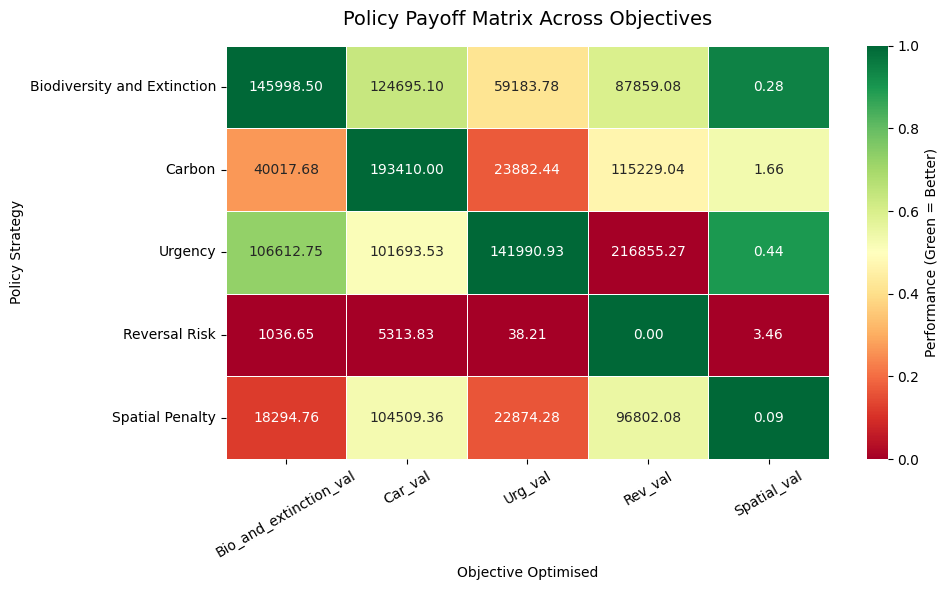

In [ ]:
norm_df = payoff_table_df.copy()

for col in norm_df.columns:
    nadir = norm_df[col].min()
    utopia = norm_df[col].max()
    norm_df[col] = (norm_df[col] - nadir) / (utopia - nadir)

# Invert Rev_val because LOWER is better
norm_df["Rev_val"] = 1 - norm_df["Rev_val"]
norm_df["Spatial_val"] = 1 - norm_df["Spatial_val"]

# ==========================================
# HEATMAP
# ==========================================

plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    norm_df,
    annot=payoff_table_df,   # show original values
    fmt=".2f",
    cmap="RdYlGn",           # red → yellow → green
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Performance (Green = Better)"}
)

plt.title("Policy Payoff Matrix Across Objectives", fontsize=14, pad=15)
plt.xlabel("Objective Optimised")
plt.ylabel("Policy Strategy")

plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("Figures/Payoff Table/Payoff_Table_Heatmap_GreenGood.png", dpi=300)
plt.show()

C:\Users\alasd\AppData\Local\Temp\ipykernel_28196\23587181.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('Set1')


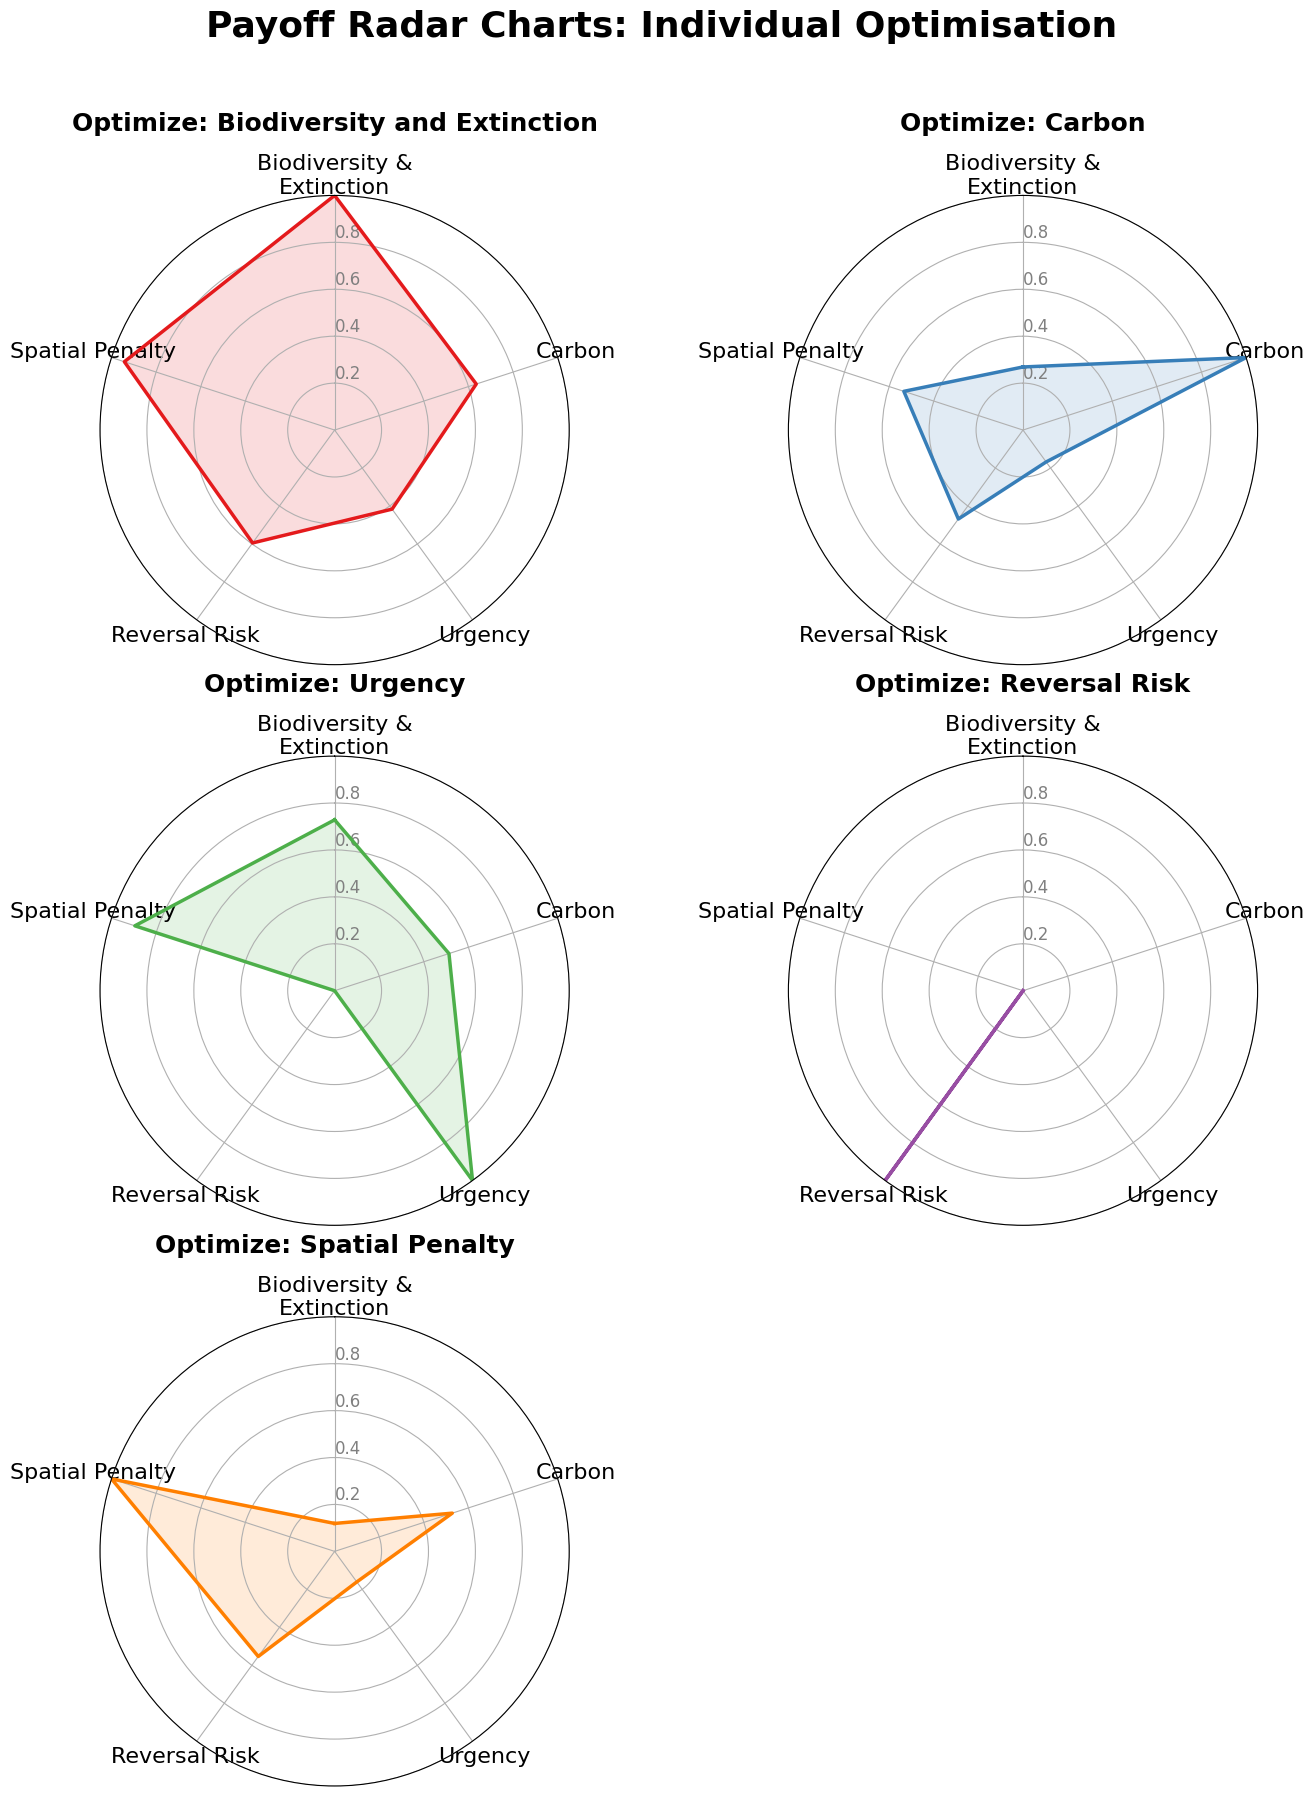

In [32]:
from math import pi
import numpy as np

# Get utopia and nadir from payoff_df for normalization
norm_df = pd.DataFrame()

# Normalize MAXIMIZE objectives (Bio, Carbon, Urgency)
for payoff_col in ['Bio_and_extinction_val', 'Car_val', 'Urg_val']:
    nadir = payoff_table_df[payoff_col].min()
    utopia = payoff_table_df[payoff_col].max()
    denom = utopia - nadir
    norm_df[payoff_col] = 1.0 if denom == 0 else (payoff_table_df[payoff_col] - nadir) / denom

# Invert Reversal Risk so 1.0 = safest (minimized objective)
rev_nadir = payoff_table_df['Rev_val'].max()
rev_utopia = payoff_table_df['Rev_val'].min()
rev_denom = rev_nadir - rev_utopia
norm_df['Rev_val'] = 1.0 if rev_denom == 0 else (rev_nadir - payoff_table_df['Rev_val']) / rev_denom

# Invert Spatial Penalty so 1.0 = least penalty (minimized objective)
spatial_nadir = payoff_table_df['Spatial_val'].max()
spatial_utopia = payoff_table_df['Spatial_val'].min()
spatial_denom = spatial_nadir - spatial_utopia
norm_df['Spatial_val'] = 1.0 if spatial_denom == 0 else (spatial_nadir - payoff_table_df['Spatial_val']) / spatial_denom

norm_df['Policy'] = payoff_table_df.index

# Setup radar chart parameters
categories = ['Biodiversity &\nExtinction', 'Carbon', 'Urgency', 'Reversal Risk', 'Spatial Penalty']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

colormap = plt.cm.get_cmap('Set1')
rows_data = list(norm_df.reset_index().iterrows())
n_charts = len(rows_data)  # no MILP chart

# Build a grid (2 columns)
n_cols = 2
n_rows = int(np.ceil(n_charts / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 6 * n_rows),
    subplot_kw=dict(polar=True)
)
axes = np.array(axes).flatten()

# Plot payoff table charts only
for i, (_, row) in enumerate(rows_data):
    ax = axes[i]
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=16)
    ax.set_rlabel_position(0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", ""], color="grey", size=12)
    ax.set_ylim(0, 1)

    values = [row['Bio_and_extinction_val'], row['Car_val'], row['Urg_val'], row['Rev_val'], row['Spatial_val']]
    values += values[:1]

    ax.plot(angles, values, color=colormap(i), linewidth=2.5, linestyle='solid')
    ax.fill(angles, values, color=colormap(i), alpha=0.15)
    ax.set_title(f"Optimize: {row['Policy']}", size=18, y=1.06, pad=26, fontweight='bold')

# Hide any unused subplot axes
for j in range(n_charts, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Payoff Radar Charts: Individual Optimisation", fontsize=26, fontweight='bold', y=0.995)

fig.subplots_adjust(hspace=0.45, wspace=0.30)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("Figures/Radar Plots/Radar_All_Policies_Single.png", dpi=300, bbox_inches='tight')
plt.show()